# Test 6 — A 1D-CNN on the peak information from Test 5

Test 5 showed that the winner's peak features (B0) generalise much better to the hidden test set (private 0.701) than CNNs on chunk statistics (0.657). B0, however, reduces each measurement to **9 averages**. This notebook gives the **same cleaned peak information** to a 1D-CNN instead, laid out around the voltage cycle, so the network can learn patterns that averages can't capture: how pulses cluster across neighbouring angles, and how the three phases relate.

**Input per measurement:** for each of the 3 phases, 10 channels over 64 phase bins (5.625° each, 0° = positive-going zero crossing), built from the Data prep v4 peak table after the winner's noise-floor and interference filters:

| Channels | Meaning |
|---|---|
| Peak count, positive count, negative count | How many true peaks fall in each bin (log-scaled) |
| Sum of relative heights | Peak heights divided by the trace's own noise floor, so they don't depend on sensor gain (log-scaled) |
| Mean sawtooth error (lengths 2 and 3), mean next and previous ratios, mean opposite-polarity offset, mean width | Average pulse shape in the bin (empty bins get the dataset average) |

**Model:** a small CNN with **circular convolutions** (0° and 360° are neighbours on the voltage cycle) that predicts one probability per measurement. Training uses **augmentation**: the order of the three phases is rotated, and the angles are shifted slightly, so the model can't rely on which phase is which or on exact angle positions.

**Evaluation: identical to Test 5.** Measurement-level folds with the same seeds as Test 5 (its first 10 repeats); in each fold, one fold for OOF predictions, the next for early stopping, the rest for training. Signal-level MCC is reported for comparison with Tests 3–5 and Kaggle.

**Pre-registered submissions:** `CNN_peaks` and its blend with B0 are both submitted, and both scores reported.

**Inputs:** the committed output of **Data prep v4**, and (for the comparison and blend) the committed output of **Test 5**. A GPU speeds training up but isn't required.

## 1. Settings

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import glob, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import matthews_corrcoef, confusion_matrix

torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

N_REPEATS, N_FOLDS, SEED_BASE = 10, 5, 1000     # same fold seeds as Test 5 (its first 10 repeats)
N_BINS = 64                                     # 5.625 degrees per bin
BATCH_SIZE, MAX_EPOCHS, PATIENCE, LR, WEIGHT_DECAY = 64, 150, 20, 1e-3, 1e-3
MAX_SHIFT = 2                                   # augmentation: random shift of up to ±2 bins
THRESHOLDS = np.arange(0.01, 0.99, 0.01)
OUT_DIR = '/kaggle/working'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device, '| PyTorch', torch.__version__)

Using device: cpu | PyTorch 2.11.0+cpu


## 2. Load the peak table

In [2]:
def find(name):
    m = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return m[0].rsplit('/', 1)[0] if m else None

D = find('peaks_train.parquet')
assert D, 'peaks_train.parquet not found: attach the committed Data prep v4 output'
meta = pd.read_csv(f'{D}/meta_train.csv')
meta_k = pd.read_csv(f'{D}/meta_kaggle_test.csv')
assert len(meta) == 8712 and len(meta_k) == 20337, 'quick-test output attached: commit Data prep v4 with LIMIT = None'

def load(split_name, m):
    p = pd.read_parquet(f'{D}/peaks_{split_name}.parquet')
    s = pd.read_csv(f'{D}/signals_{split_name}.csv')[['signal_id', 'knee_height']]
    p = p.merge(m[['signal_id', 'id_measurement', 'phase']], on='signal_id').merge(s, on='signal_id')
    p = p[~((p['ratio_next'] > 1 / 3) & (p['height'] > 50))]          # winner's interference filter
    p['rel_height'] = p['height'] / p['knee_height'].clip(lower=1e-6)
    p['abs_dist'] = p['small_dist_to_min'].abs().astype(np.float32)
    p['bin'] = (p['phase_deg'] / (360 / N_BINS)).astype(int).clip(0, N_BINS - 1)
    return p

peaks, peaks_k = load('train', meta), load('kaggle_test', meta_k)
print(f'Peaks after filtering: {len(peaks):,} labelled, {len(peaks_k):,} Kaggle test')

Peaks after filtering: 1,222,983 labelled, 2,498,770 Kaggle test


## 3. Build the phase-resolved peak grids

Each measurement becomes an array of shape (3 phases × 10 channels, 64 bins). Count and height channels are summed per bin and log-scaled; shape channels are averaged per bin, with empty bins set to the average over all peaks, so "no peak" doesn't look like an extreme value.

In [3]:
COUNT_CH = ['count', 'count_pos', 'count_neg', 'sum_rel_height']
MEAN_CH = ['sawtooth_2', 'sawtooth_3', 'ratio_next', 'ratio_prev', 'abs_dist', 'width']
CHANNELS = COUNT_CH + MEAN_CH
FILL = peaks[MEAN_CH].astype(float).mean()

def build_grid(p, m):
    ids = np.sort(m['id_measurement'].unique())
    row = pd.Series(np.arange(len(ids)), index=ids)
    r, ph, b = row.loc[p['id_measurement']].values, p['phase'].values, p['bin'].values
    G = np.zeros((len(ids), 3, len(CHANNELS), N_BINS), dtype=np.float32)
    ones = np.ones(len(p), dtype=np.float32)
    np.add.at(G, (r, ph, 0, b), ones)
    np.add.at(G, (r, ph, 1, b), (p['sign'].values > 0).astype(np.float32))
    np.add.at(G, (r, ph, 2, b), (p['sign'].values < 0).astype(np.float32))
    np.add.at(G, (r, ph, 3, b), p['rel_height'].values.astype(np.float32))
    counts = G[:, :, 0, :].copy()
    for j, c in enumerate(MEAN_CH, start=len(COUNT_CH)):
        np.add.at(G, (r, ph, j, b), p[c].values.astype(np.float32))
        G[:, :, j, :] = np.where(counts > 0, G[:, :, j, :] / np.maximum(counts, 1), FILL[c])
    G[:, :, :len(COUNT_CH), :] = np.log1p(G[:, :, :len(COUNT_CH), :])
    return ids, G.reshape(len(ids), 3 * len(CHANNELS), N_BINS)

ids_all, G = build_grid(peaks, meta)
ids_k, G_k = build_grid(peaks_k, meta_k)
y_meas = meta.groupby('id_measurement')['target'].max().loc[ids_all].values
split = meta.groupby('id_measurement')['split'].first().loc[ids_all].values
pool = np.where(np.isin(split, ['train', 'val']))[0]
test_rows = np.where(split == 'test')[0]
pool_ids = ids_all[pool]
yp = y_meas[pool]
pool_sig = meta[meta['id_measurement'].isin(pool_ids)]
print('Grid:', G.shape, '| Kaggle:', G_k.shape, f'| pool: {len(pool)} measurements ({yp.sum()} PD)')

Grid: (2904, 30, 64) | Kaggle: (6779, 30, 64) | pool: 2468 measurements (165 PD)


## 4. Where peaks occur: PD vs normal measurements

Average peak count per bin (all three phases combined), for PD and normal measurements in the pool. This is the same kind of phase-resolved picture as in Test 4, now built from the winner's cleaned peaks.

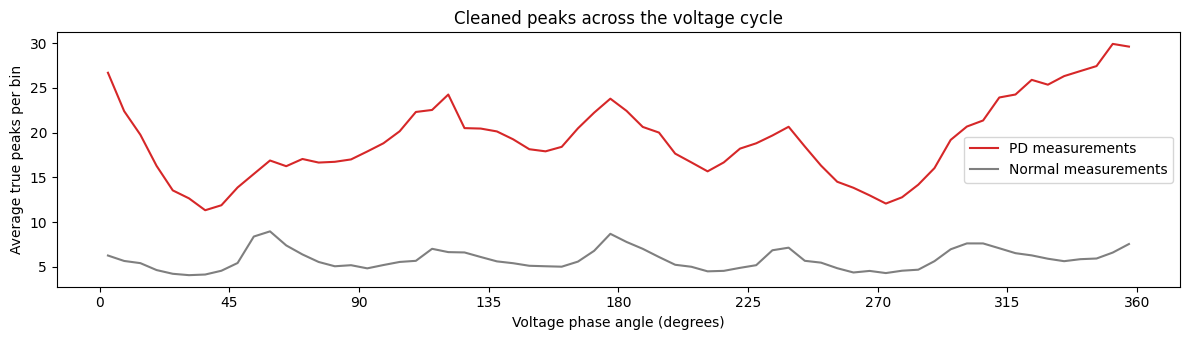

In [4]:
cnt = np.expm1(G[pool].reshape(len(pool), 3, len(CHANNELS), N_BINS)[:, :, 0, :]).sum(axis=1)
angles = (np.arange(N_BINS) + 0.5) * 360 / N_BINS
plt.figure(figsize=(12, 3.5))
plt.plot(angles, cnt[yp == 1].mean(0), color='tab:red', label='PD measurements')
plt.plot(angles, cnt[yp == 0].mean(0), color='tab:gray', label='Normal measurements')
plt.xticks(range(0, 361, 45)); plt.xlabel('Voltage phase angle (degrees)'); plt.ylabel('Average true peaks per bin')
plt.title('Cleaned peaks across the voltage cycle'); plt.legend(); plt.tight_layout(); plt.show()

## 5. The model

`PeakCNN`: three convolution blocks with **circular padding** (so a pattern spanning 360°→0° is seen as continuous), batch normalisation, ReLU and pooling (64 → 32 → 16 bins), then a small classifier with dropout. Flattening keeps the information about *where* in the cycle patterns occur.

**Augmentation during training (per batch):** the three phases are rotated in order (phase 0→1→2→0, chosen at random), and all bins are shifted together by up to ±2 bins (±11°).

In [5]:
N_CH = 3 * len(CHANNELS)

class PeakCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def block(ci, co, k, pool):
            layers = [nn.Conv1d(ci, co, k, padding=k // 2, padding_mode='circular'), nn.BatchNorm1d(co), nn.ReLU()]
            return nn.Sequential(*layers, nn.MaxPool1d(2)) if pool else nn.Sequential(*layers)
        self.features = nn.Sequential(block(N_CH, 32, 5, False), block(32, 32, 5, True), block(32, 64, 3, True))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), nn.Linear(64 * (N_BINS // 4), 32),
                                        nn.ReLU(), nn.Dropout(0.5), nn.Linear(32, 1))
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

def augment(xb, gen):
    k = int(torch.randint(0, 3, (1,), generator=gen))
    xb = torch.roll(xb.view(len(xb), 3, len(CHANNELS), N_BINS), shifts=k, dims=1).view(len(xb), N_CH, N_BINS)
    s = int(torch.randint(-MAX_SHIFT, MAX_SHIFT + 1, (1,), generator=gen))
    return torch.roll(xb, shifts=s, dims=2)

print(f'PeakCNN: {sum(p.numel() for p in PeakCNN().parameters()):,} parameters')

PeakCNN: 49,281 parameters


## 6. Training function

Per fold: channel-wise normalisation from the training part, class-weighted loss, Adam with weight decay, and early stopping on the **separate stopping fold's loss** (smoother than MCC with so few PD measurements per fold). Returns predictions for the OOF fold, the internal test measurements and the Kaggle test measurements.

In [6]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def predict(model, X):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), 512):
            out.append(torch.sigmoid(model(torch.tensor(X[i:i + 512], device=device))).cpu().numpy())
    return np.concatenate(out)

def train_fold(tr, st, va, seed):
    mean = G[tr].mean(axis=(0, 2), keepdims=True); std = G[tr].std(axis=(0, 2), keepdims=True) + 1e-6
    norm = lambda a: ((a - mean) / std).astype(np.float32)
    Xtr, Xst = torch.tensor(norm(G[tr]), device=device), torch.tensor(norm(G[st]), device=device)
    ytr, yst = torch.tensor(y_meas[tr], dtype=torch.float32, device=device), torch.tensor(y_meas[st], dtype=torch.float32, device=device)
    set_seed(seed); gen = torch.Generator(); gen.manual_seed(seed)
    model = PeakCNN().to(device)
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([(len(tr) - y_meas[tr].sum()) / y_meas[tr].sum()], device=device))
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best, best_state, waited = np.inf, None, 0
    for epoch in range(MAX_EPOCHS):
        model.train()
        perm = torch.randperm(len(tr), generator=gen)
        for i in range(0, len(tr), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE].to(device)
            opt.zero_grad(); loss = crit(model(augment(Xtr[idx], gen)), ytr[idx]); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            stop_loss = crit(model(Xst), yst).item()
        if stop_loss < best:
            best, waited = stop_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            waited += 1
            if waited >= PATIENCE:
                break
    model.load_state_dict(best_state)
    return predict(model, norm(G[va])), predict(model, norm(G[test_rows])), predict(model, norm(G_k))

## 7. Cross-validation (10 repeats × 5 folds)

In [7]:
oof = np.zeros((N_REPEATS, len(pool)))
pred_test, pred_k = np.zeros(len(test_rows)), np.zeros(len(G_k))
n_models = N_REPEATS * N_FOLDS
t0 = time.time()
for r in range(N_REPEATS):
    fold = np.zeros(len(pool), dtype=int)
    for k, (_, va) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED_BASE + r).split(pool, yp)):
        fold[va] = k
    for k in range(N_FOLDS):
        va, st = fold == k, fold == (k + 1) % N_FOLDS
        tr = ~(va | st)
        p_va, p_te, p_k = train_fold(pool[tr], pool[st], pool[va], SEED_BASE + r)
        oof[r, va] = p_va; pred_test += p_te / n_models; pred_k += p_k / n_models
    print(f'repeat {r + 1}/{N_REPEATS} done | {(time.time() - t0) / 60:.1f} min')

repeat 1/10 done | 1.1 min
repeat 2/10 done | 2.6 min
repeat 3/10 done | 3.6 min
repeat 4/10 done | 5.0 min
repeat 5/10 done | 6.2 min
repeat 6/10 done | 7.2 min
repeat 7/10 done | 8.7 min
repeat 8/10 done | 9.8 min
repeat 9/10 done | 11.3 min
repeat 10/10 done | 12.5 min


## 8. Results and blend with B0

The CNN is scored exactly as in Test 5. If Test 5's output is attached, its B0 predictions are loaded, and a **calibrated blend** (`w × CNN + (1 − w) × B0`, w chosen on OOF predictions) is evaluated. As in Test 5, calibration and w are chosen on the same OOF predictions, so the blend's OOF score is slightly optimistic.

In [8]:
def to_signal(p, ids, m):
    return m['id_measurement'].map(pd.Series(p, index=ids)).values

def best_signal_cut(p):
    ps, ys = to_signal(p, pool_ids, pool_sig), pool_sig['target'].values
    scores = np.array([matthews_corrcoef(ys, ps > t) for t in THRESHOLDS])
    tied = np.flatnonzero(scores == scores.max())        # if several cut-offs tie, take the middle one
    i = int(tied[len(tied) // 2]); return float(scores[i]), float(THRESHOLDS[i])

def meas_mcc(p):
    return max(matthews_corrcoef(yp, p > t) for t in THRESHOLDS)

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))

def calibrator(p, y):
    lr = LogisticRegression(C=1e6).fit(logit(p)[:, None], y)
    return lambda q: lr.predict_proba(logit(q)[:, None])[:, 1]

results = {'CNN_peaks': dict(oof=oof, kaggle=pred_k)}
T5 = find('test5_predictions.npz')
if T5:
    d = np.load(f'{T5}/test5_predictions.npz')
    b0_oof = pd.Series(d['oof_B0_winner'], index=d['pool_ids']).loc[pool_ids].values
    b0_k = pd.Series(d['kaggle_B0_winner'], index=d['kaggle_ids']).loc[ids_k].values
    cnn_oof = oof.mean(0)
    cc, cb = calibrator(cnn_oof, yp), calibrator(b0_oof, yp)
    W = max(((best_signal_cut(w * cc(cnn_oof) + (1 - w) * cb(b0_oof))[0], w) for w in [0, 0.25, 0.5, 0.75, 1]))[1]
    results['Blend_CNNpeaks_B0'] = dict(oof=(W * cc(cnn_oof) + (1 - W) * cb(b0_oof))[None, :], kaggle=W * cc(pred_k) + (1 - W) * cb(b0_k), weight=W)
    print(f'Blend: chosen CNN weight w = {W}')
else:
    print('Test 5 output not attached: blend skipped')

rows, cuts = [], {}
for name, r in results.items():
    ens = r['oof'].mean(0)
    per_rep = [meas_mcc(r['oof'][i]) for i in range(len(r['oof']))]
    sig, cut = best_signal_cut(ens); cuts[name] = cut
    tn, fp, fn, tp = confusion_matrix(pool_sig['target'].values, to_signal(ens, pool_ids, pool_sig) > cut).ravel()
    rows.append({'Approach': name, 'Meas. MCC per repeat (mean)': round(np.mean(per_rep), 3),
                 'Meas. MCC per repeat (SD)': round(np.std(per_rep), 3) if len(per_rep) > 1 else None,
                 'Ensemble OOF MCC (measurement)': round(meas_mcc(ens), 3), 'Signal-level MCC': round(sig, 3),
                 'Cut-off': round(cut, 2), 'Recall': f'{tp / (tp + fn):.1%}', 'Precision': f'{tp / (tp + fp):.1%}',
                 'False alarms': f'{fp} of {fp + tn}'})
summary6 = pd.DataFrame(rows)
summary6.to_csv(f'{OUT_DIR}/test6_summary.csv', index=False)

t5s = find('test5_summary.csv')
if t5s:
    print('Test 5 reference:'); print(pd.read_csv(f'{t5s}/test5_summary.csv')[['Approach', 'Signal-level MCC']].to_string(index=False)); print()
summary6

Blend: chosen CNN weight w = 0
Test 5 reference:
  Approach  Signal-level MCC
 B0_winner             0.726
B1_adapted             0.753



,Approach,Meas. MCC per repeat (mean),Meas. MCC per repeat (SD),Ensemble OOF MCC (measurement),Signal-level MCC,Cut-off,Recall,Precision,False alarms
0,CNN_peaks,0.682,0.014,0.704,0.684,0.89,73.5%,67.5%,160 of 6952
1,Blend_CNNpeaks_B0,0.751,NaN,0.751,0.726,0.46,71.2%,77.2%,95 of 6952


## 9. Submission files

Following the pre-registered plan, **submit both files** and report both scores.

In [9]:
for name, r in results.items():
    p_sig = to_signal(r['kaggle'], ids_k, meta_k)
    sub = pd.DataFrame({'signal_id': meta_k['signal_id'], 'target': (p_sig > cuts[name]).astype(int)})
    sub.to_csv(f'{OUT_DIR}/submission_{name}.csv', index=False)
    print(f'submission_{name}.csv: {sub["target"].sum()} predicted PD ({sub["target"].mean():.1%})')
np.savez(f'{OUT_DIR}/test6_predictions.npz', pool_ids=pool_ids, kaggle_ids=ids_k, test_ids=ids_all[test_rows],
         oof_CNN_peaks=oof.mean(0), kaggle_CNN_peaks=pred_k, test_CNN_peaks=pred_test)
with open(f'{OUT_DIR}/test6_settings.json', 'w') as f:
    json.dump({'cutoffs': cuts, 'blend_weight': results.get('Blend_CNNpeaks_B0', {}).get('weight')}, f, indent=2)

submission_CNN_peaks.csv: 867 predicted PD (4.3%)
submission_Blend_CNNpeaks_B0.csv: 744 predicted PD (3.7%)
